In [ ]:
import pandas as pd

# Load the dataset into a DataFrame
# A DataFrame is like a spreadsheet inside Python
df = pd.read_csv("Sentiment_Mental_health_dataset.csv")

# Show the first 5 rows
print(df.head())

                                           statement                status
0  Anyone else have symptoms much improved after ...               Bipolar
1  I basicaly do not exist, sure feels that way. ...              Suicidal
2  Finding a sense of self It's like one minute I...  Personality_disorder
3  Putting into words what were just tangles in m...               Anxiety
4  Anxiety makes me worry about my public image s...               Anxiety


In [ ]:
# How many rows and columns does the dataset have?
print(df.shape)

# What are the column names?
print(df.columns)

# How many examples of each status label do we have?
print(df["status"].value_counts())

(26350, 2)
Index(['statement', 'status'], dtype='object')
status
Suicidal                5600
Anxiety                 4704
Normal                  4575
Depression              4111
Personality_disorder    2817
Bipolar                 2720
Stress                  1823
Name: count, dtype: int64


In [ ]:
# Check for any missing values
print(df.isnull().sum())

# Show one full statement so we can read it properly
print(df["statement"][0])

statement    0
status       0
dtype: int64
Anyone else have symptoms much improved after leaving a spouse/SO I don't think I'm "better." I'm still on my meds and see my docs as appropriate, but after leaving my spouse of 15 years 9 months ago, my symptoms have been reduced to almost nothing, and my doctor was able to reduce my medications by 25%.

It certainly helped that I stopped drinking and using pot in that time frame, but I don't think I would have been able to do that in my old relationship. Only now can I look back and see what an emotional burden my ex-SO had been, and how her crazy-making had so severely impacted my emotional health. I don't "blame" her for my mental illness, but I *do* think having her in my life was detrimental to my mental health on so, so many levels. I still feel the occasional phantom twinge of anxiety before I remind myself I don't have to go home to her anymore. I can still sometimes feel my mind running on old tracks laid by her that are of no longer

In [ ]:
# Print the first statement exactly as it is in the raw data
print(df["statement"][0])

Anyone else have symptoms much improved after leaving a spouse/SO I don't think I'm "better." I'm still on my meds and see my docs as appropriate, but after leaving my spouse of 15 years 9 months ago, my symptoms have been reduced to almost nothing, and my doctor was able to reduce my medications by 25%.

It certainly helped that I stopped drinking and using pot in that time frame, but I don't think I would have been able to do that in my old relationship. Only now can I look back and see what an emotional burden my ex-SO had been, and how her crazy-making had so severely impacted my emotional health. I don't "blame" her for my mental illness, but I *do* think having her in my life was detrimental to my mental health on so, so many levels. I still feel the occasional phantom twinge of anxiety before I remind myself I don't have to go home to her anymore. I can still sometimes feel my mind running on old tracks laid by her that are of no longer of use to me.

Has anyone else experienced

In [ ]:
# Convert all text to lowercase
# .str.lower() makes every letter small
# This ensures Anxiety and anxiety are treated as the same word
df["statement"] = df["statement"].str.lower()

# Check it worked - print the same statement again
print(df["statement"][0])

anyone else have symptoms much improved after leaving a spouse/so i don't think i'm "better." i'm still on my meds and see my docs as appropriate, but after leaving my spouse of 15 years 9 months ago, my symptoms have been reduced to almost nothing, and my doctor was able to reduce my medications by 25%.

it certainly helped that i stopped drinking and using pot in that time frame, but i don't think i would have been able to do that in my old relationship. only now can i look back and see what an emotional burden my ex-so had been, and how her crazy-making had so severely impacted my emotional health. i don't "blame" her for my mental illness, but i *do* think having her in my life was detrimental to my mental health on so, so many levels. i still feel the occasional phantom twinge of anxiety before i remind myself i don't have to go home to her anymore. i can still sometimes feel my mind running on old tracks laid by her that are of no longer of use to me.

has anyone else experienced

In [ ]:
# Step 2 - Remove URLs
# re is a library for finding patterns in text
import re

# re.sub() finds a pattern and replaces it with something
# r'http\S+|www\S+' means: find anything starting with http or www
# '' means: replace it with nothing (delete it)
# str(x) converts the value to text just in case
df["statement"] = df["statement"].apply(lambda x: re.sub(r'http\S+|www\S+', '', str(x)))

print(df["statement"][0])

anyone else have symptoms much improved after leaving a spouse/so i don't think i'm "better." i'm still on my meds and see my docs as appropriate, but after leaving my spouse of 15 years 9 months ago, my symptoms have been reduced to almost nothing, and my doctor was able to reduce my medications by 25%.

it certainly helped that i stopped drinking and using pot in that time frame, but i don't think i would have been able to do that in my old relationship. only now can i look back and see what an emotional burden my ex-so had been, and how her crazy-making had so severely impacted my emotional health. i don't "blame" her for my mental illness, but i *do* think having her in my life was detrimental to my mental health on so, so many levels. i still feel the occasional phantom twinge of anxiety before i remind myself i don't have to go home to her anymore. i can still sometimes feel my mind running on old tracks laid by her that are of no longer of use to me.

has anyone else experienced

In [ ]:
# Check a statement that had a URL before cleaning
print(df["statement"][4])

anxiety makes me worry about my public image so. damn. much. i'm so fucking sick of overthinking every action, every conversation, every message just absolutely fucking everything. i'm always thinking about how anything i do can be perceived and how that might damage my public image just so i don't make a fool of myself or make myself look negative in any way. it's so tiring to plan nearly everything i do. i hate it.


In [ ]:
# Step 3 — Remove punctuation and numbers
# [^a-z\s] means: find anything that is NOT a letter or a space
# ^ inside brackets means NOT
# a-z means any lowercase letter
# \s means any space
# Anything that doesn't match gets replaced with nothing
df["statement"] = df["statement"].apply(lambda x: re.sub(r'[^a-z\s]', '', str(x)))

print(df["statement"][0])

anyone else have symptoms much improved after leaving a spouseso i dont think im better im still on my meds and see my docs as appropriate but after leaving my spouse of  years  months ago my symptoms have been reduced to almost nothing and my doctor was able to reduce my medications by 

it certainly helped that i stopped drinking and using pot in that time frame but i dont think i would have been able to do that in my old relationship only now can i look back and see what an emotional burden my exso had been and how her crazymaking had so severely impacted my emotional health i dont blame her for my mental illness but i do think having her in my life was detrimental to my mental health on so so many levels i still feel the occasional phantom twinge of anxiety before i remind myself i dont have to go home to her anymore i can still sometimes feel my mind running on old tracks laid by her that are of no longer of use to me

has anyone else experienced this where a notsogreat marriage a

In [ ]:
# Step 4 — Remove extra spaces
# .str.strip() removes spaces from the start and end
# .str.replace() replaces multiple spaces in a row with a single space
df["statement"] = df["statement"].str.strip()
df["statement"] = df["statement"].str.replace(r'\s+', ' ', regex=True)

print(df["statement"][0])

anyone else have symptoms much improved after leaving a spouseso i dont think im better im still on my meds and see my docs as appropriate but after leaving my spouse of years months ago my symptoms have been reduced to almost nothing and my doctor was able to reduce my medications by it certainly helped that i stopped drinking and using pot in that time frame but i dont think i would have been able to do that in my old relationship only now can i look back and see what an emotional burden my exso had been and how her crazymaking had so severely impacted my emotional health i dont blame her for my mental illness but i do think having her in my life was detrimental to my mental health on so so many levels i still feel the occasional phantom twinge of anxiety before i remind myself i dont have to go home to her anymore i can still sometimes feel my mind running on old tracks laid by her that are of no longer of use to me has anyone else experienced this where a notsogreat marriage an unh

In [ ]:
# Check no missing values were created during cleaning
print(df.isnull().sum())

# Check how many rows we still have
print(df.shape)

# Save the cleaned dataset so we don't have to repeat this
df.to_csv("cleaned_mental_health_dataset.csv", index=False)

print("Cleaned dataset saved.")

statement    0
status       0
dtype: int64
(26350, 2)
Cleaned dataset saved.


In [ ]:
import pandas as pd

df = pd.read_csv("cleaned_mental_health_dataset.csv")
print(df.shape)
print(df.head())

(26350, 2)
                                           statement                status
0  anyone else have symptoms much improved after ...               Bipolar
1  i basicaly do not exist sure feels that way no...              Suicidal
2  finding a sense of self its like one minute im...  Personality_disorder
3  putting into words what were just tangles in m...               Anxiety
4  anxiety makes me worry about my public image s...               Anxiety


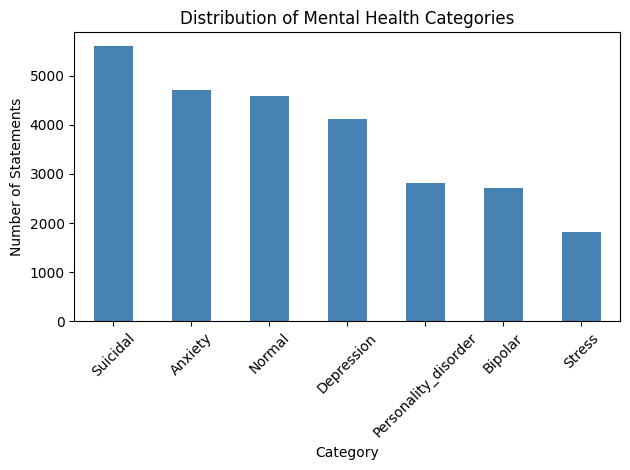

In [ ]:
import matplotlib.pyplot as plt

# Count each label and plot as a bar chart
df["status"].value_counts().plot(kind="bar", color="steelblue")

# Add labels and title
plt.title("Distribution of Mental Health Categories")
plt.xlabel("Category")
plt.ylabel("Number of Statements")
plt.xticks(rotation=45)  # Rotate labels so they don't overlap
plt.tight_layout()       # Makes sure nothing gets cut off
plt.show()

In [ ]:
# Print 2 example statements from each category

for label in df["status"].unique():
    print(f"\n--- {label} ---")
    examples = df[df["status"] == label]["statement"].head(2)
    for ex in examples:
      print(ex)
      print()


--- Bipolar ---
anyone else have symptoms much improved after leaving a spouseso i dont think im better im still on my meds and see my docs as appropriate but after leaving my spouse of years months ago my symptoms have been reduced to almost nothing and my doctor was able to reduce my medications by it certainly helped that i stopped drinking and using pot in that time frame but i dont think i would have been able to do that in my old relationship only now can i look back and see what an emotional burden my exso had been and how her crazymaking had so severely impacted my emotional health i dont blame her for my mental illness but i do think having her in my life was detrimental to my mental health on so so many levels i still feel the occasional phantom twinge of anxiety before i remind myself i dont have to go home to her anymore i can still sometimes feel my mind running on old tracks laid by her that are of no longer of use to me has anyone else experienced this where a notsogrea

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# X = the statements (input), y = the labels (what we want to predict)
X = df["statement"]
y = df["status"]

# Convert text to numbers — max 10,000 most common words
vectoriser = TfidfVectorizer(max_features=10000)
X_vectorised = vectoriser.fit_transform(X)

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorised, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

ValueError: np.nan is an invalid document, expected byte or unicode string.

In [ ]:
# Remove any rows where the statement is empty or NaN
df = df.dropna(subset=["statement"])

# Also remove any rows where statement is just whitespace
df = df[df["statement"].str.strip() != ""]

print("Rows after cleaning:", df.shape[0])

Rows after cleaning: 26312


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# X = the statements (input), y = the labels (what we want to predict)
X = df["statement"]
y = df["status"]

# Convert text to numbers — max 10,000 most common words
vectoriser = TfidfVectorizer(max_features=10000)
X_vectorised = vectoriser.fit_transform(X)

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorised, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 21049
Testing samples: 5263


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model on the training data
# This is where the model learns patterns from 21,049 statements
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Use the model to predict labels for the test set
y_pred = model.predict(X_test)

# Overall accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed breakdown per category
print(classification_report(y_test, y_pred))

Accuracy: 0.7681930457913737
                      precision    recall  f1-score   support

             Anxiety       0.78      0.82      0.80       988
             Bipolar       0.83      0.66      0.74       532
          Depression       0.60      0.57      0.58       832
              Normal       0.92      0.98      0.95       879
Personality_disorder       0.82      0.75      0.78       546
              Stress       0.90      0.59      0.71       371
            Suicidal       0.69      0.82      0.75      1115

            accuracy                           0.77      5263
           macro avg       0.79      0.74      0.76      5263
        weighted avg       0.77      0.77      0.77      5263



In [ ]:
import re

# Function to classify any new text
def classify_statement(text):
    # Clean the input the same way we cleaned the training data
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = text.strip()

    # Convert to numbers using the same vectoriser
    text_vectorised = vectoriser.transform([text])

    # Predict the category
    prediction = model.predict(text_vectorised)
    return prediction[0]

# Test it with a sample statement
print(classify_statement("I feel completely alone and nobody understands me"))

Suicidal


In [ ]:
print(classify_statement("I feel like breaking down every other day because I have no friends I feel lonely and don't feel like doing anything. I have a total lack of interest in daily activities and my motivation is nonexistent"))
print(classify_statement("I feel like tha pain in my foot is not going away but otherwise I am trying to work on my routine and eating well but yeah it is a bit difficult to manage time"))

Depression
Stress
